In [1]:
%pip install networkx matplotlib pydot

Note: you may need to restart the kernel to use updated packages.


In [2]:
%load_ext autoreload
%autoreload 2

import cpg_trie_parser as cpg

In [38]:
from pathlib import Path
import pydot
import networkx as nx

dot_path = Path("services/frontend/export.dot")

dot_text = dot_path.read_text(encoding="utf-8")
graphs = pydot.graph_from_dot_data(dot_text)

P = graphs[0]
P

KeyboardInterrupt: 

In [4]:
G = nx.MultiDiGraph()

for node in P.get_nodes():
    name = node.get_name()
    if name in (None, "node", "graph", "edge"):
        continue
    nid = str(name).strip('"')
    attrs = {k: v for k, v in node.get_attributes().items()}
    G.add_node(nid, **attrs)

for edge in P.get_edges():
    src = str(edge.get_source()).strip('"')
    dst = str(edge.get_destination()).strip('"')
    attrs = {k: v for k, v in edge.get_attributes().items()}
    G.add_edge(src, dst, **attrs)

print(G.number_of_nodes(), G.number_of_edges())

30548 164385


In [5]:
from typing import List, Tuple
import csv

def extract_logs(dataset_path: str, service: str, start_time: int, end_time: int) -> List[Tuple[str, str]]:
    logs = []
    try:
        with open(dataset_path, 'r') as f:
            reader = csv.reader(f)
            next(reader, None)
            for row in reader:
                if len(row) < 3:
                    continue
                try:
                    timestamp   = int(float(row[0]))
                    log_service = row[1].strip()
                    message     = row[2].strip()
                    if log_service.lower() == service.lower() and start_time <= timestamp <= end_time:
                        bucket = f"{log_service}@{timestamp}"
                        logs.append((bucket, message))
                except (ValueError, IndexError):
                    continue
    except FileNotFoundError:
        print(f"ERROR: Dataset file not found: {dataset_path}")
    print(f"✓ Extracted {len(logs)} logs for {service} in time window")
    return logs

In [6]:
dataset = "./dataset/re3ob_adservice_f3_1/logs.csv"
service = "frontend"
start = 1731903974
end = 1731903980
logs = extract_logs(dataset, service, start, end)

✓ Extracted 107 logs for frontend in time window


In [7]:
templates = cpg.build_templates_from_cpg(G, max_ddg_depth=5)
root = cpg.build_trie(templates)
cpg.visualize_trie_matplotlib(root, output_path="trie.png")

[Trie] Saved matplotlib PNG -> trie.png


In [8]:
print("Templates:", len(templates))
for t in templates[:10]:
    print(f"[{t.call_node_id}] {t.method_name}() -> {t.raw_template} (static={t.static_count})")

Templates: 77
[30064771307] loadDeploymentDetails() -> failed to fetch the hostname for the pod <*> (static=8)
[30064771312] loadDeploymentDetails() -> failed to fetch the name of the cluster in which the pod is running <*> (static=14)
[30064771317] loadDeploymentDetails() -> failed to fetch the zone of the node where the pod is scheduled <*> (static=13)
[30064771328] loadDeploymentDetails() -> loaded deployment details <*> (static=3)
[30064772872] AddItem() -> method additem not implemented <*> (static=4)
[30064772874] GetCart() -> method getcart not implemented <*> (static=4)
[30064772876] EmptyCart() -> method emptycart not implemented <*> (static=4)
[30064772938] ListRecommendations() -> method listrecommendations not implemented <*> (static=4)
[30064772994] ListProducts() -> method listproducts not implemented <*> (static=4)
[30064772996] GetProduct() -> method getproduct not implemented <*> (static=4)


In [9]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [10]:
import pandas as pd

mappings = cpg.map_logs(logs, root, templates, min_static=1)
print(f"Mappings: {len(mappings)}\n")

rows = []
for m in mappings:
    rows.append({
        "bucket":          m.bucket,
        "matched":         "✓" if m.matched else "✗",
        "method_name":     m.method_name if m.method_name else "—",
        "template":        m.template    if m.template    else "—",
        "score":           m.score,
        "call_node_id":    m.call_node_id    if m.call_node_id    else "—",
        "method_node_id":  m.method_node_id  if m.method_node_id  else "—",
        "message":         m.message,
    })

df = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.max_rows", 200)
df

Mappings: 107



,bucket,matched,method_name,template,score,call_node_id,method_node_id,message
0,frontend@1731903974,✓,ServeHTTP,request started <*>,2,30064774247,107374182800,request started
1,frontend@1731903974,✓,productHandler,serving product page <*>,3,30064773422,107374182767,serving product page
2,frontend@1731903974,✗,—,—,0,—,—,request complete
3,frontend@1731903974,✗,—,—,0,—,—,request complete
4,frontend@1731903974,✓,ServeHTTP,request started <*>,2,30064774247,107374182800,request started
5,frontend@1731903974,✓,addToCartHandler,adding to cart <*>,3,30064773495,107374182768,adding to cart
6,frontend@1731903974,✗,—,—,0,—,—,request complete
7,frontend@1731903974,✓,ServeHTTP,request started <*>,2,30064774247,107374182800,request started
8,frontend@1731903974,✓,viewCartHandler,view user cart <*>,3,30064773548,107374182770,view user cart
9,frontend@1731903974,✗,—,—,0,—,—,request complete


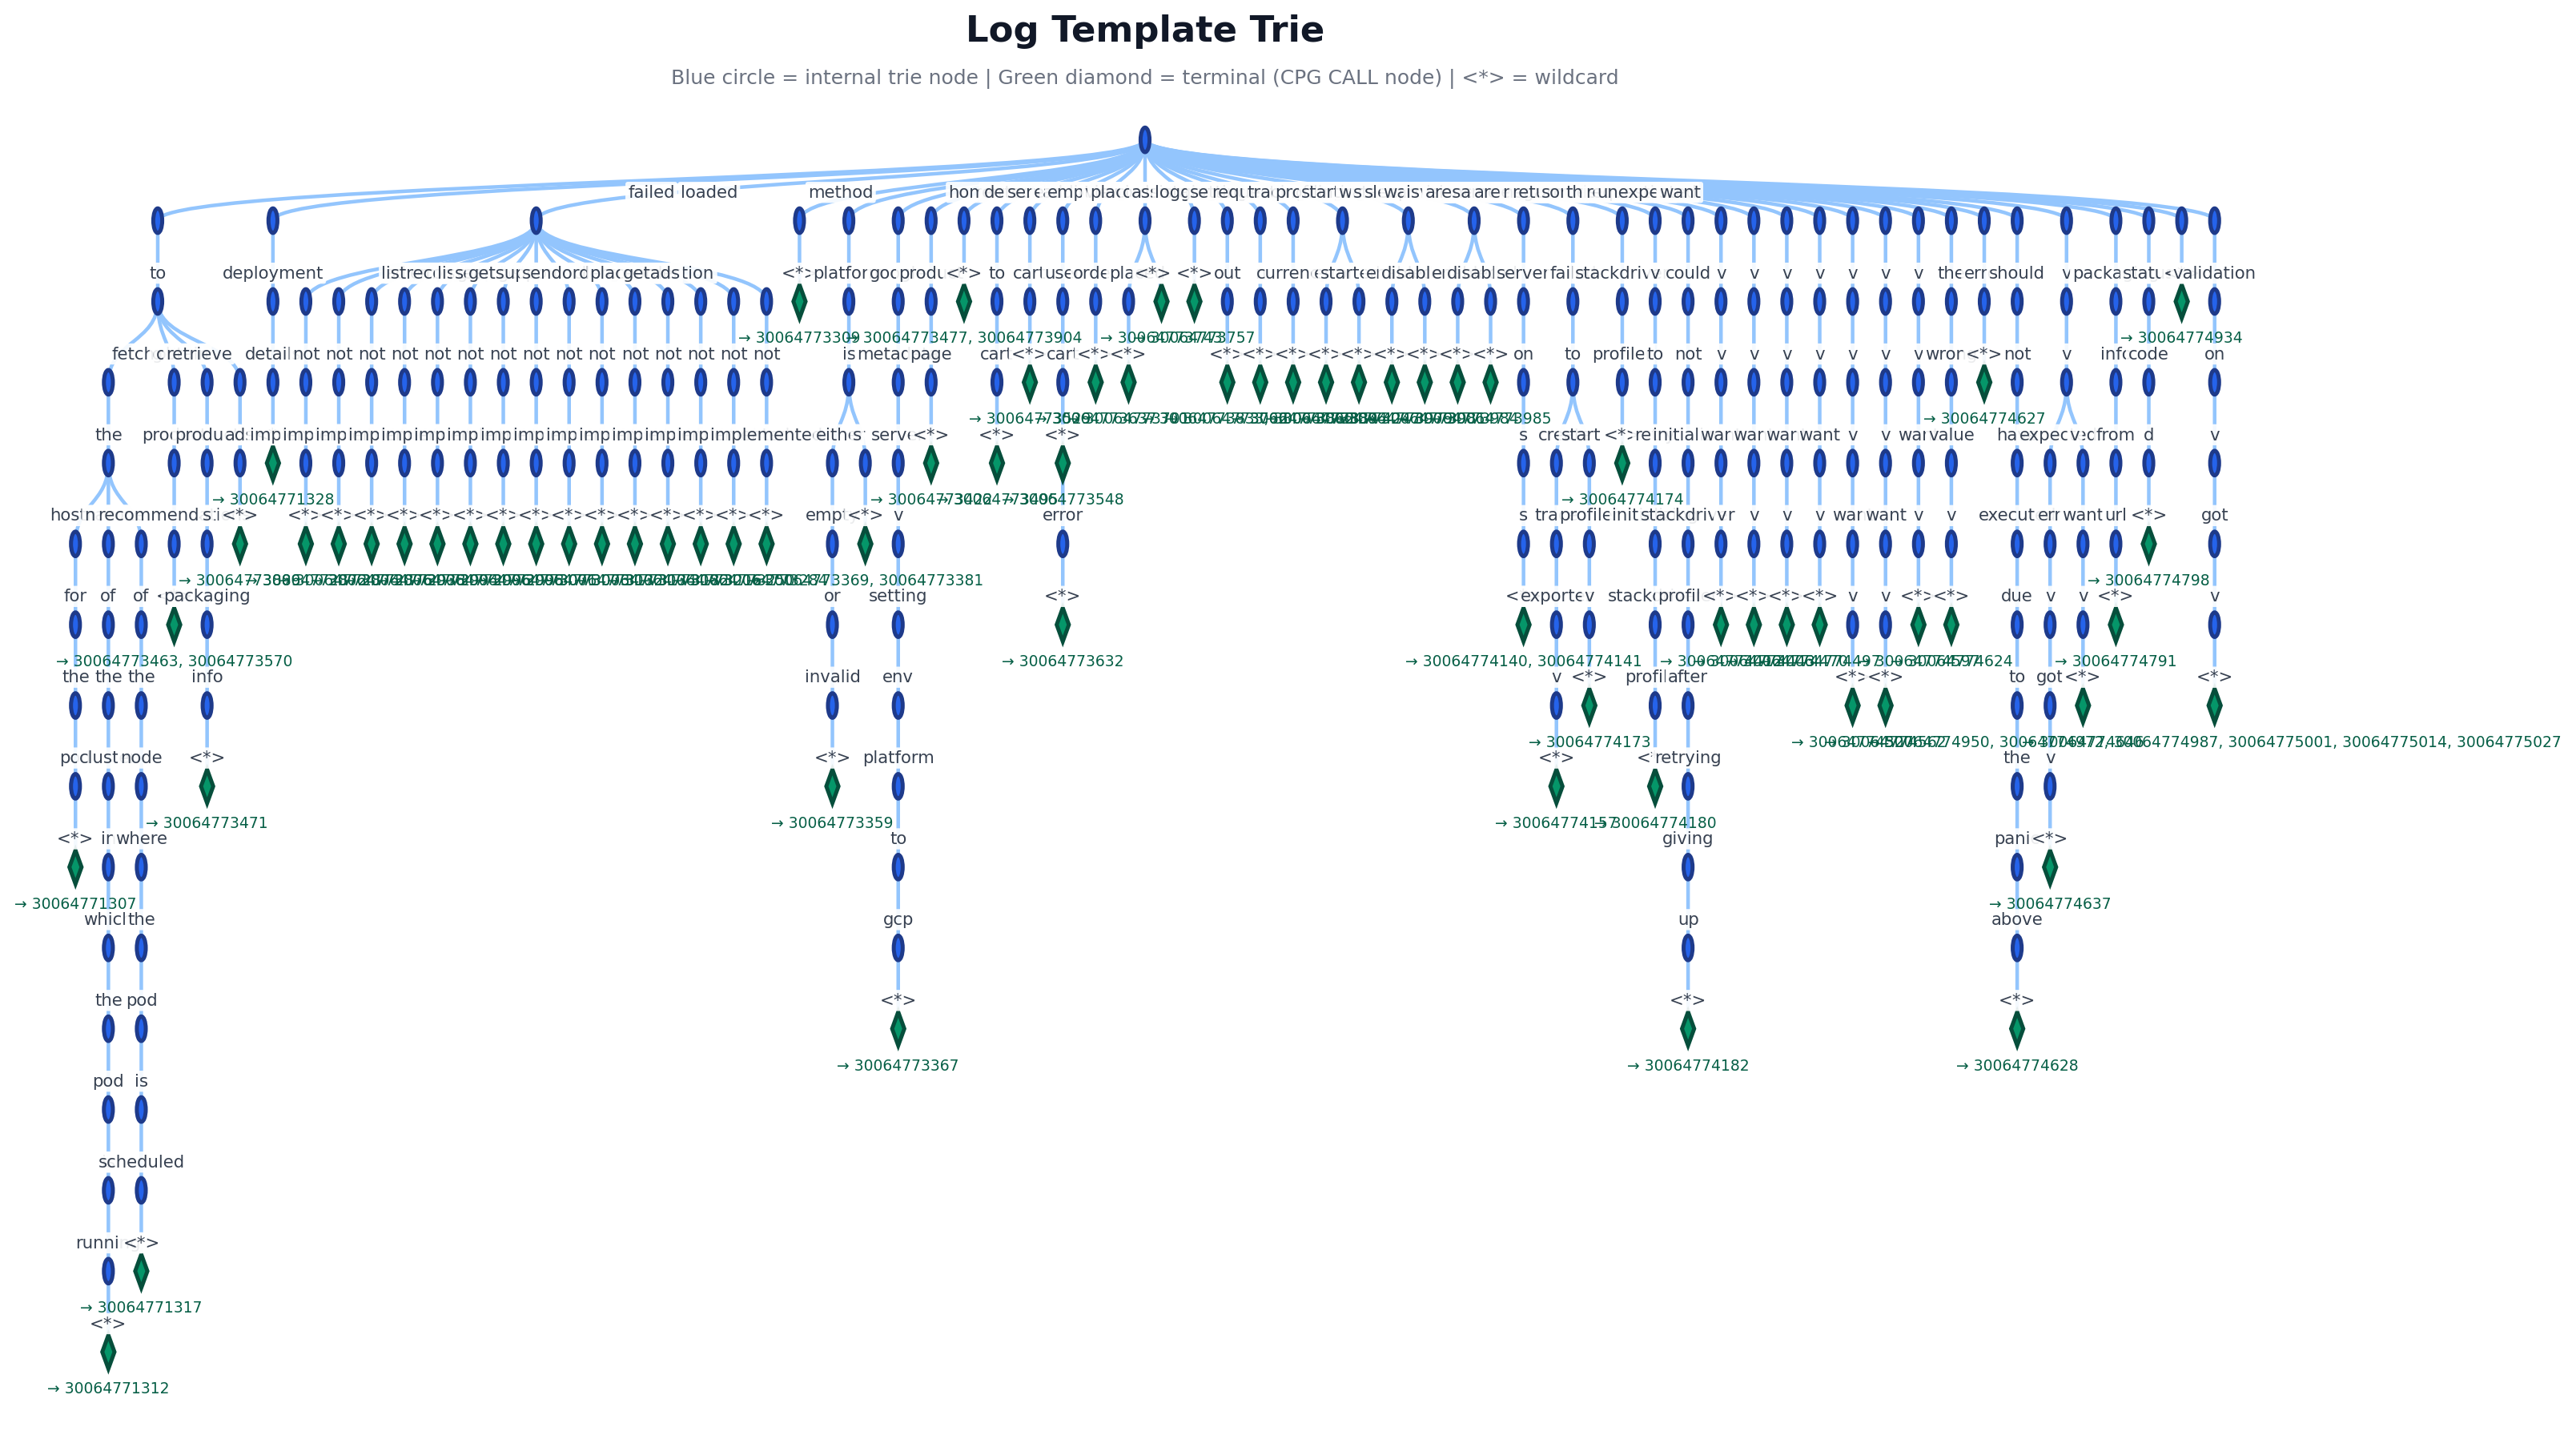

In [11]:
from IPython.display import Image, display
display(Image(filename="trie.png"))

In [41]:
import pandas as pd
from collections import defaultdict

# ── Шаг 1: маппинг логов с добавлением full_name ──────────────────────────
mappings = cpg.map_logs(logs, root, templates, min_static=1)

# Быстрый lookup: method_node_id → full_name
node_to_fullname = {
    nid: data.get("FULL_NAME", "")
    for nid, data in G.nodes(data=True)
    if data.get("label") == '"METHOD"'
}

rows = []
for m in mappings:
    full_name = node_to_fullname.get(m.method_node_id, "—") if m.method_node_id else "—"
    rows.append({
        "bucket":         m.bucket,
        "matched":        "✓" if m.matched else "✗",
        "method_name":    m.method_name    if m.method_name    else "—",
        "full_name":      full_name,                              # ← новое поле
        "template":       m.template       if m.template       else "—",
        "score":          m.score,
        "call_node_id":   m.call_node_id   if m.call_node_id   else "—",
        "method_node_id": m.method_node_id if m.method_node_id else "—",
        "message":        m.message,
    })

df = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.max_rows", 200)
display(df)

,bucket,matched,method_name,full_name,template,score,call_node_id,method_node_id,message
0,frontend@1731903974,✓,ServeHTTP,—,request started <*>,2,30064774247,107374182800,request started
1,frontend@1731903974,✓,productHandler,—,serving product page <*>,3,30064773422,107374182767,serving product page
2,frontend@1731903974,✗,—,—,—,0,—,—,request complete
3,frontend@1731903974,✗,—,—,—,0,—,—,request complete
4,frontend@1731903974,✓,ServeHTTP,—,request started <*>,2,30064774247,107374182800,request started
5,frontend@1731903974,✓,addToCartHandler,—,adding to cart <*>,3,30064773495,107374182768,adding to cart
6,frontend@1731903974,✗,—,—,—,0,—,—,request complete
7,frontend@1731903974,✓,ServeHTTP,—,request started <*>,2,30064774247,107374182800,request started
8,frontend@1731903974,✓,viewCartHandler,—,view user cart <*>,3,30064773548,107374182770,view user cart
9,frontend@1731903974,✗,—,—,—,0,—,—,request complete


In [42]:
# ── Шаг 2: цепочки вызовов по bucket ──────────────────────────────────────
transactions = defaultdict(list)
for m in mappings:
    if not m.matched: continue
    transactions[m.bucket].append({
        "method_name":    m.method_name,
        "method_node_id": m.method_node_id,
        "full_name":      node_to_fullname.get(m.method_node_id, "—"),
    })

def split_into_requests(steps):
    requests, current = [], []
    for step in steps:
        if step["method_name"] == "ServeHTTP":
            if current: requests.append(current)
            current = [step]
        else:
            current.append(step)
    if current: requests.append(current)
    return requests

print(f"{'bucket':<25} {'#':>2}  chain")
print("─" * 80)
for bucket, steps in sorted(transactions.items()):
    for i, req in enumerate(split_into_requests(steps)):
        # Короткие имена для читаемости
        short_chain = " → ".join(s["method_name"] for s in req)
        # Полные имена (full_name)
        full_chain  = " → ".join(s["full_name"]   for s in req)
        print(f"{bucket:<25} {i:>2}  {short_chain}")
        print(f"{'':>28}  {full_chain}")
        print()

bucket                     #  chain
────────────────────────────────────────────────────────────────────────────────
frontend@1731903974        0  ServeHTTP → productHandler
                              — → —

frontend@1731903974        1  ServeHTTP → addToCartHandler
                              — → —

frontend@1731903974        2  ServeHTTP → viewCartHandler
                              — → —

frontend@1731903975        0  ServeHTTP → productHandler → chooseAd
                              — → — → —

frontend@1731903975        1  ServeHTTP → productHandler → chooseAd
                              — → — → —

frontend@1731903976        0  ServeHTTP → productHandler
                              — → —

frontend@1731903976        1  ServeHTTP → productHandler → chooseAd
                              — → — → —

frontend@1731903976        2  ServeHTTP → addToCartHandler
                              — → —

frontend@1731903976        3  ServeHTTP → viewCartHandler → chooseAd
            

In [46]:
def get_method_subgraphs_fixed(method_node_id):
    # 1. Все ноды по AST вниз
    method_nodes = set()
    queue = [method_node_id]
    while queue:
        cur = queue.pop()
        if cur in method_nodes: continue
        method_nodes.add(cur)
        for src, dst, data in G.out_edges(cur, data=True):
            lbl = data.get("label", "").strip('"')   # ← зачищаем кавычки
            if lbl == "AST":
                queue.append(dst)

    # 2. Собираем все рёбра внутри метода с зачисткой label
    cfg = nx.DiGraph()
    pdg = nx.DiGraph()
    
    for nid in method_nodes:
        d = G.nodes[nid]
        attrs = dict(
            label=d.get("label","").strip('"'),
            code=d.get("CODE","").strip('"')[:60],
            line=d.get("LINE_NUMBER","").strip('"'),
        )
        cfg.add_node(nid, **attrs)
        pdg.add_node(nid, **attrs)

    for src, dst, data in G.edges(data=True):
        if src not in method_nodes or dst not in method_nodes:
            continue
        lbl = data.get("label", "").strip('"')   # ← зачищаем
        if lbl == "CFG":
            cfg.add_edge(src, dst)
        elif lbl in ("CDG", "REACHING_DEF"):
            pdg.add_edge(src, dst, dep_type=lbl)

    return cfg, pdg, method_nodes

# Пересобираем method_graphs с исправленной функцией
method_graphs = {}
for m in mappings:
    if not m.matched or not m.method_node_id: continue
    if m.method_name in method_graphs: continue
    cfg, pdg, _ = get_method_subgraphs_fixed(m.method_node_id)
    method_graphs[m.method_name] = {
        "method_node_id": m.method_node_id,
        "cfg": cfg, "pdg": pdg,
    }
    print(f"{m.method_name:25s}  CFG: {cfg.number_of_edges():3d} рёбер  PDG: {pdg.number_of_edges():3d} рёбер")

ServeHTTP                  CFG:  75 рёбер  PDG: 204 рёбер
productHandler             CFG: 193 рёбер  PDG: 545 рёбер
addToCartHandler           CFG: 126 рёбер  PDG: 355 рёбер
viewCartHandler            CFG: 224 рёбер  PDG: 654 рёбер
chooseAd                   CFG:  26 рёбер  PDG:  85 рёбер
placeOrderHandler          CFG: 264 рёбер  PDG: 864 рёбер
homeHandler                CFG: 205 рёбер  PDG: 581 рёбер
setCurrencyHandler         CFG:  96 рёбер  PDG: 264 рёбер


C:\Users\Zevsoverlord\AppData\Local\Temp\ipykernel_10200\3900341223.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Zevsoverlord\AppData\Local\Temp\ipykernel_10200\3900341223.py:153: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.savefig(fname, dpi=150, bbox_inches="tight")


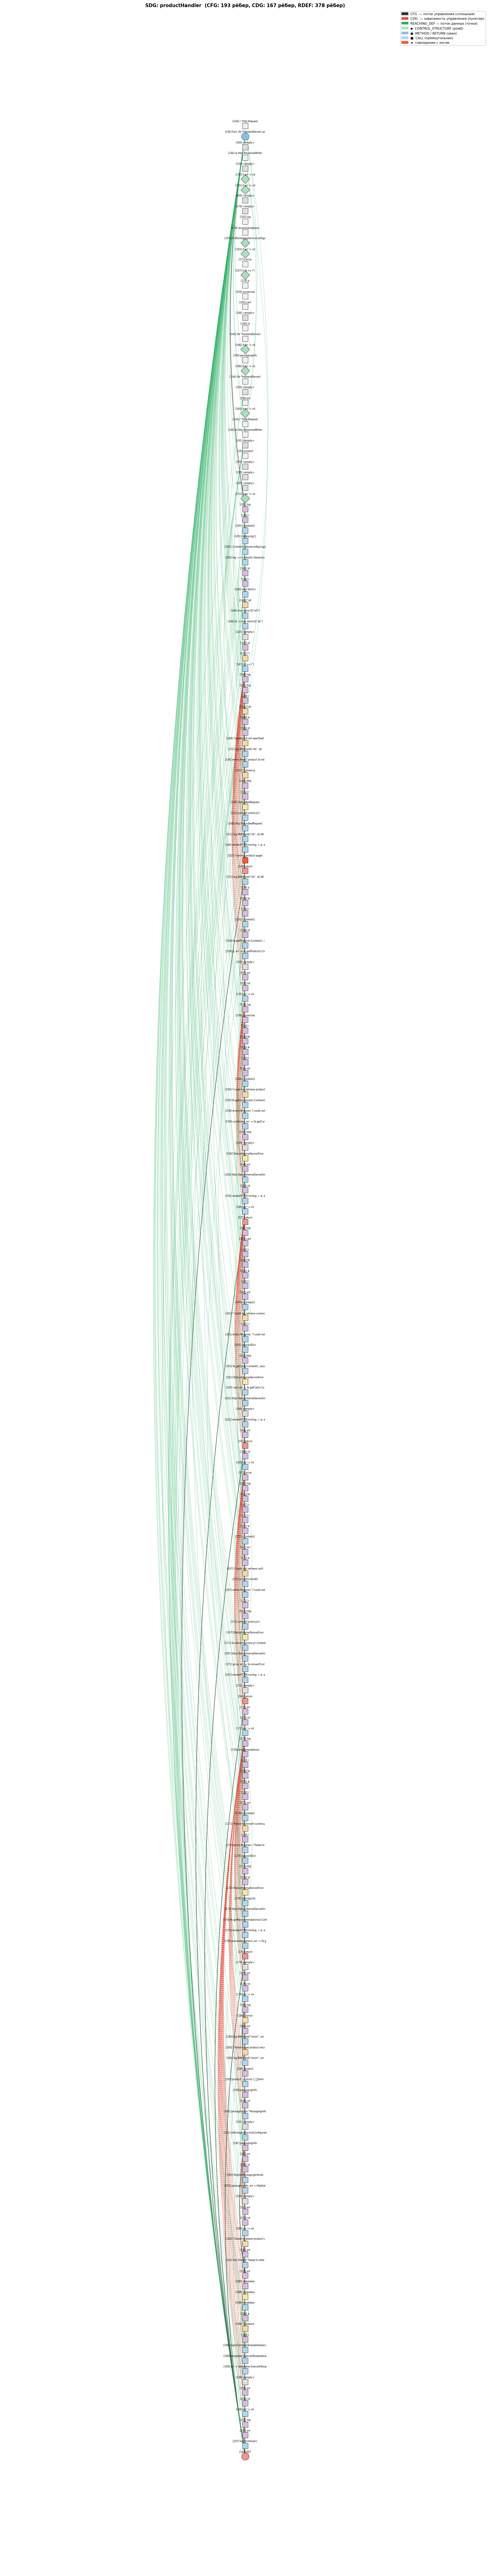

Сохранено: sdg_productHandler.png


In [49]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import networkx as nx

def visualize_unified_cfg_pdg(method_name, method_graphs, highlight_messages=None):
    cfg = method_graphs[method_name]["cfg"]
    pdg = method_graphs[method_name]["pdg"]

    # Единый граф: все ноды + оба типа рёбер с атрибутом edge_kind
    unified = nx.MultiDiGraph()
    for nid, d in cfg.nodes(data=True):
        unified.add_node(nid, **d)
    for src, dst in cfg.edges():
        unified.add_edge(src, dst, edge_kind="CFG")
    for src, dst, d in pdg.edges(data=True):
        unified.add_edge(src, dst, edge_kind=d.get("dep_type", "CDG"))

    # Топологический порядок по CFG (от входа к выходу)
    try:
        order = list(nx.topological_sort(cfg))
    except nx.NetworkXUnfeasible:
        entry = next((n for n in cfg.nodes if cfg.in_degree(n) == 0), list(cfg.nodes)[0])
        order = list(nx.dfs_preorder_nodes(cfg, entry))

    # Позиции через graphviz dot (строго сверху вниз)
    try:
        pos = nx.nx_agraph.graphviz_layout(cfg, prog="dot")
    except Exception:
        # Fallback: по порядку топосортировки, x=0 для линейных, разброс для ветвлений
        pos = {nid: (0, -i * 55) for i, nid in enumerate(order)}

    # ── Форма ноды по типу (стандартная нотация) ─────────────────────────
    # CONTROL_STRUCTURE → ромб, METHOD/METHOD_RETURN → овал, остальные → прямоугольник
    # Реализуем через цвет + marker в scatter (matplotlib не поддерживает mixed shapes в draw)
    # Используем draw_networkx_nodes отдельно для каждой группы

    SHAPE_GROUPS = {
        "diamond": ["CONTROL_STRUCTURE"],          # ромб — условие
        "oval":    ["METHOD", "METHOD_RETURN"],    # овал — вход/выход
        "rect":    ["CALL", "RETURN", "BLOCK",
                    "IDENTIFIER", "LITERAL",
                    "FIELD_IDENTIFIER", "JUMP_TARGET"],
    }

    TYPE_COLORS = {
        "CALL":              "#AED6F1",   # голубой
        "RETURN":            "#F1948A",   # красный
        "CONTROL_STRUCTURE": "#A9DFBF",   # зелёный
        "LITERAL":           "#FAD7A0",   # оранжевый
        "IDENTIFIER":        "#D7BDE2",   # фиолетовый
        "BLOCK":             "#DEDEDE",   # серый
        "METHOD":            "#85C1E9",   # синий
        "METHOD_RETURN":     "#F1948A",   # красный
        "FIELD_IDENTIFIER":  "#F9E79F",   # жёлтый
        "JUMP_TARGET":       "#FDFEFE",   # белый
    }

    def get_group(lbl):
        for shape, types in SHAPE_GROUPS.items():
            if lbl in types: return shape
        return "rect"

    # Метки
    labels = {}
    for nid, d in unified.nodes(data=True):
        lbl  = d.get("label", "")
        code = d.get("code", "")[:28].replace("\n", " ")
        line = d.get("line", "")
        labels[nid] = f"[{line}] {code}" if code else f"[{line}] {lbl}"

    # Подсветка
    hit_nodes = set()
    if highlight_messages:
        for nid, d in unified.nodes(data=True):
            code = d.get("code", "").lower()
            if any(msg.lower() in code for msg in highlight_messages):
                hit_nodes.add(nid)

    h = max(12, len(unified.nodes) * 0.38)
    fig, ax = plt.subplots(figsize=(16, h))
    ax.set_title(f"SDG: {method_name}  "
                 f"(CFG: {cfg.number_of_edges()} рёбер, "
                 f"CDG: {sum(1 for _,_,d in pdg.edges(data=True) if d.get('dep_type')=='CDG')} рёбер, "
                 f"RDEF: {sum(1 for _,_,d in pdg.edges(data=True) if d.get('dep_type')=='REACHING_DEF')} рёбер)",
                 fontsize=11, fontweight="bold")

    all_nodes = list(unified.nodes())

    # ── Рисуем ноды по группам ────────────────────────────────────────────
    for nid in all_nodes:
        d    = unified.nodes[nid]
        lbl  = d.get("label", "")
        color = "#FF5733" if nid in hit_nodes else TYPE_COLORS.get(lbl, "#F0F0F0")
        shape = get_group(lbl)
        x, y  = pos.get(nid, (0, 0))

        if shape == "diamond":
            marker, size = "D", 220
        elif shape == "oval":
            marker, size = "o", 300
        else:
            marker, size = "s", 180

        ax.scatter(x, y, s=size, c=color, marker=marker,
                   zorder=3, edgecolors="#333", linewidths=0.7)

    # ── Метки нод ─────────────────────────────────────────────────────────
    for nid, (x, y) in pos.items():
        ax.annotate(labels.get(nid, ""), (x, y),
                    fontsize=5.5, ha="center", va="bottom",
                    xytext=(0, 8), textcoords="offset points", zorder=4)

    # ── Рёбра ─────────────────────────────────────────────────────────────
    EDGE_STYLES = {
        "CFG":          dict(color="#333333", lw=1.2, ls="-",  alpha=0.85),
        "CDG":          dict(color="#E74C3C", lw=0.9, ls="--", alpha=0.7),
        "REACHING_DEF": dict(color="#27AE60", lw=0.8, ls=":",  alpha=0.6),
    }

    for src, dst, d in unified.edges(data=True):
        if src not in pos or dst not in pos: continue
        kind  = d.get("edge_kind", "CFG")
        style = EDGE_STYLES.get(kind, EDGE_STYLES["CFG"])
        x1, y1 = pos[src]
        x2, y2 = pos[dst]
        ax.annotate("",
            xy=(x2, y2), xytext=(x1, y1),
            arrowprops=dict(
                arrowstyle="->" if kind == "CFG" else "->",
                color=style["color"],
                lw=style["lw"],
                linestyle=style["ls"],
                alpha=style["alpha"],
                connectionstyle="arc3,rad=0.08",
            ), zorder=2)

    # ── Легенда ───────────────────────────────────────────────────────────
    legend_handles = [
        mpatches.Patch(color="#333333",  label="CFG  — поток управления (сплошная)"),
        mpatches.Patch(color="#E74C3C",  label="CDG  — зависимость управления (пунктир)"),
        mpatches.Patch(color="#27AE60",  label="REACHING_DEF — поток данных (точки)"),
        mpatches.Patch(color="#A9DFBF",  label="◆  CONTROL_STRUCTURE (ромб)"),
        mpatches.Patch(color="#85C1E9",  label="●  METHOD / RETURN (овал)"),
        mpatches.Patch(color="#AED6F1",  label="■  CALL (прямоугольник)"),
        mpatches.Patch(color="#FF5733",  label="★  совпадение с логом"),
    ]
    ax.legend(handles=legend_handles, fontsize=7.5, loc="upper right",
              framealpha=0.95)
    ax.axis("off")
    plt.tight_layout()
    fname = f"sdg_{method_name}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Сохранено: {fname}")


# Запуск
visualize_unified_cfg_pdg(
    "productHandler",
    method_graphs,
    highlight_messages=["serving product page"]
)

In [50]:
def print_method_source(method_name, method_graphs):
    """
    Восстанавливает исходный код метода из CFG-нод по номеру строки.
    """
    cfg = method_graphs[method_name]["cfg"]

    # Собираем все ноды с кодом и номером строки
    lines = {}
    for nid, d in cfg.nodes(data=True):
        line = d.get("line", "")
        code = d.get("code", "").strip('"').strip()
        lbl  = d.get("label", "")

        if not line or not code or lbl in ("BLOCK", "METHOD_RETURN"):
            continue

        try:
            lineno = int(line)
        except ValueError:
            continue

        # Берём самый длинный code для строки (CALL/CONTROL_STRUCTURE содержат полную строку)
        if lineno not in lines or len(code) > len(lines[lineno]["code"]):
            lines[lineno] = {"code": code, "label": lbl, "nid": nid}

    # Печатаем в порядке строк
    print(f"\n{'─'*70}")
    print(f"  Source: {method_name}")
    print(f"{'─'*70}")
    for lineno in sorted(lines.keys()):
        d   = lines[lineno]
        lbl = d["label"]
        # Отступ: BLOCK/CONTROL_STRUCTURE = меньше отступа
        indent = "    " if lbl in ("CALL", "IDENTIFIER", "RETURN", "LITERAL") else ""
        print(f"  {lineno:>4} │ {indent}{d['code']}")
    print(f"{'─'*70}\n")

    return lines   # словарь lineno → {code, label, nid}


# Запуск для всех методов транзакции
for name in method_graphs:
    src_lines = print_method_source(name, method_graphs)


──────────────────────────────────────────────────────────────────────
  Source: ServeHTTP
──────────────────────────────────────────────────────────────────────
    57 │ func (lh *logHandler) ServeHTTP(w http.ResponseWriter, r *ht
    58 │     ctx := r.Context()
    59 │     requestID, _ := uuid.NewRandom()
    60 │     context.WithValue(ctx, ctxKeyRequestID{}, requestID.String()
    62 │     start := time.Now()
    63 │     rr := &responseRecorder{w: w}
    64 │     logrus.Fields{
		\"http.req.path\":   r.URL.Path,
		\"http.r
    65 │     r.URL.Path
    66 │     r.Method
    67 │     requestID.String()
    69 │     v, ok := r.Context().Value(ctxKeySessionID{}).(string)
    70 │     log = log.WithField(\"session\", v)
    72 │     log.Debug(\"request started\")
    80 │     ctx = context.WithValue(ctx, ctxKeyLog{}, log)
    81 │     r = r.WithContext(ctx)
    82 │     lh.next.ServeHTTP(rr, r)
──────────────────────────────────────────────────────────────────────


───────────────────


──────────────────────────────────────────────────────────────────────
  Source: productHandler  (★ = совпадение с логом)
──────────────────────────────────────────────────────────────────────
   144 │ func (fe *frontendServer) productHandler(w http.ResponseWrit
   145 │ log := r.Context().Value(ctxKeyLog{}).(logrus.FieldLogger)
   146 │ id := mux.Vars(r)[\"id\"]
   147 │ if id == \"\
   148 │ renderHTTPError(log, r, w, errors.New(\"product id not speci
   149 │ return
   151 │ log.WithField(\"id\", id).WithField(\"currency\", currentCur
   152 │ \"serving product page\ ★ LOG
   154 │ p, err := fe.getProduct(r.Context(), id)
   155 │ if err != nil
   156 │ renderHTTPError(log, r, w, errors.Wrap(err, \"could not retr
   157 │ return
   159 │ currencies, err := fe.getCurrencies(r.Context())
   160 │ if err != nil
   161 │ renderHTTPError(log, r, w, errors.Wrap(err, \"could not retr
   162 │ return
   165 │ cart, err := fe.getCart(r.Context(), sessionID(r))
   166 │ if err != nil
   167 

C:\Users\Zevsoverlord\AppData\Local\Temp\ipykernel_10200\3900341223.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Zevsoverlord\AppData\Local\Temp\ipykernel_10200\3900341223.py:153: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.savefig(fname, dpi=150, bbox_inches="tight")


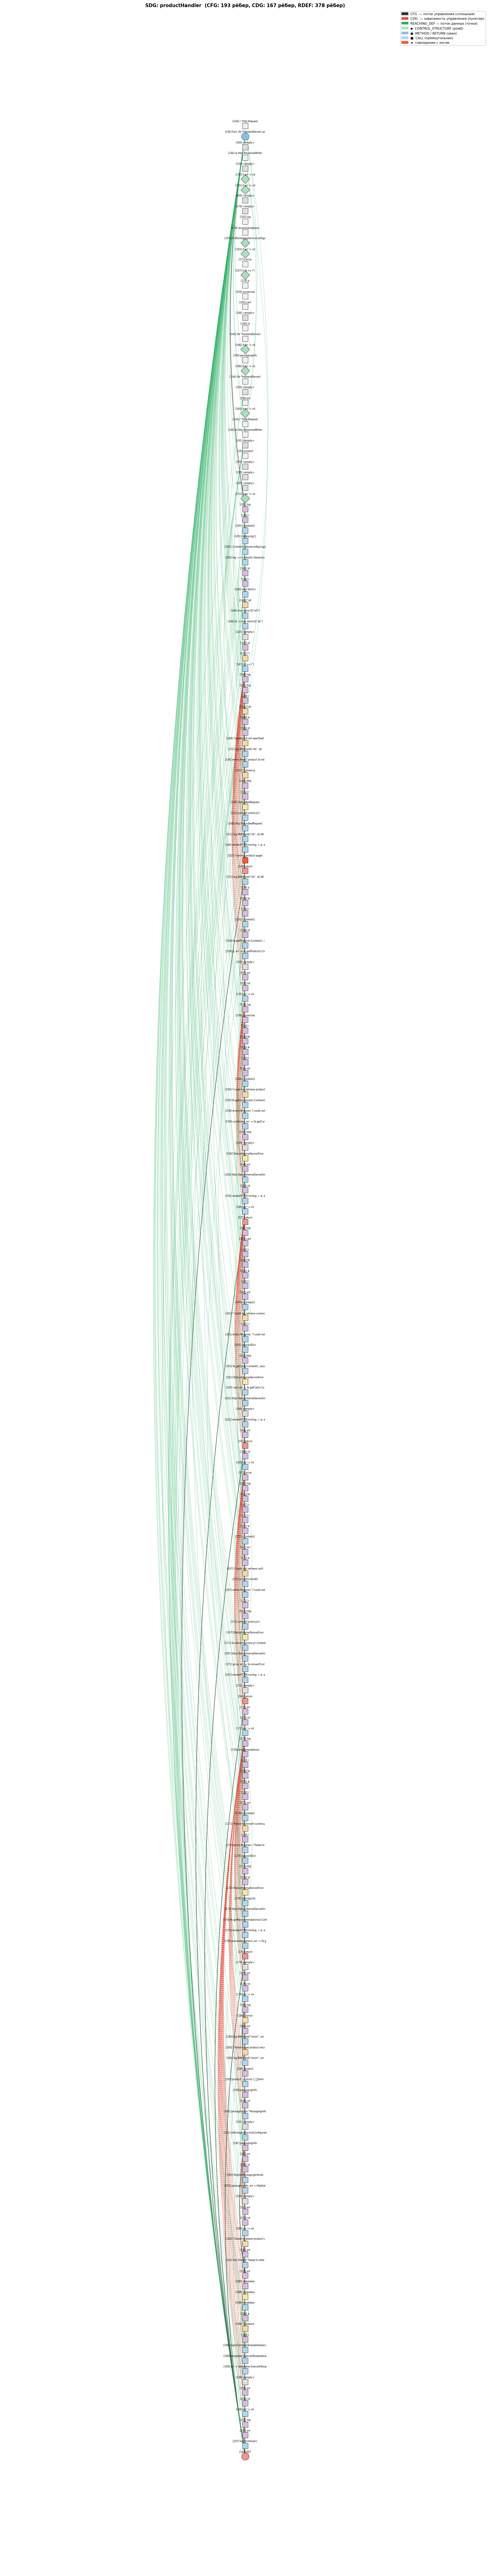

Сохранено: sdg_productHandler.png


In [53]:
def highlight_log_in_source(method_name, method_graphs, log_messages):
    """Выводит исходник с пометкой строк, совпадающих с логами."""
    src_lines = print_method_source.__wrapped__ \
        if hasattr(print_method_source, '__wrapped__') \
        else None
    
    cfg = method_graphs[method_name]["cfg"]
    lines = {}
    for nid, d in cfg.nodes(data=True):
        line = d.get("line",""); code = d.get("code","").strip('"').strip()
        lbl  = d.get("label","")
        if not line or not code or lbl in ("BLOCK","METHOD_RETURN"): continue
        try: lineno = int(line)
        except: continue
        if lineno not in lines or len(code) > len(lines[lineno]["code"]):
            lines[lineno] = {"code": code, "label": lbl}

    print(f"\n{'─'*70}")
    print(f"  Source: {method_name}  (★ = совпадение с логом)")
    print(f"{'─'*70}")
    for lineno in sorted(lines.keys()):
        code = lines[lineno]["code"]
        hit  = any(msg.lower() in code.lower() for msg in log_messages)
        mark = " ★ LOG" if hit else ""
        print(f"  {lineno:>4} │ {code}{mark}")
    print(f"{'─'*70}\n")


# Выбираем метод для просмотра
method_name = "productHandler"   # ← меняйте здесь

# 1. Исходный код с подсветкой логов
log_messages = [m.message for m in mappings 
                if m.matched and m.method_name == method_name]

highlight_log_in_source(method_name, method_graphs, log_messages)

# 2. Граф
visualize_unified_cfg_pdg(method_name, method_graphs, highlight_messages=log_messages)

In [ ]:
def get_method_name(node_id, method_graphs):
    for name, mg in method_graphs.items():
        if mg["method_node_id"] == node_id:
            return name
    return node_to_fullname.get(node_id, str(node_id))

def cpg_pareto_traceroute(G, entry_node_id, crash_node_id,
                           anchor_node_ids, live_weights, hist_median,
                           method_graphs, node_to_fullname):
    """
    1. Forward Pareto  от entry  → вперёд по CALL с весами из логов
    2. Backward Pareto от crash  → назад  по CALL с историческими медианами
    3. Встреча фронтов → полный ранжированный путь
    """

    # ── CALL-граф прямой и обратный ───────────────────────────────────────
    call_graph = nx.DiGraph()
    for src, dst, data in G.edges(data=True):
        if data.get("label", "").strip('"') == "CALL":
            call_graph.add_edge(src, dst)
    call_graph_rev = call_graph.reverse(copy=True)

    # ── Парето-утилиты ────────────────────────────────────────────────────
    def dominates_anomalous(p, q):
        return p[0] >= q[0] and p[1] >= q[1] and p != q

    def pareto_add(front, new_cost):
        """Добавляем new_cost во фронт если не доминируется. Возвращает (front, added)."""
        if any(dominates_anomalous(c, new_cost) for c in front):
            return front, False
        pruned = [c for c in front if not dominates_anomalous(new_cost, c)]
        pruned.append(new_cost)
        return pruned, True

    def get_w(src, dst, weights, median):
        """Вес ребра: из логов или медиана"""
        return weights.get((src, dst), median.get(dst, (1.0, 1.0)))

    def is_normal(cost, dst, median):
        """Путь штатный — ниже медианы по обоим измерениям → выбрасываем"""
        m = median.get(dst, (1.0, 1.0))
        return cost[0] <= m[0] and cost[1] <= m[1]

    # ── Forward: entry → все достижимые ноды ─────────────────────────────
    fwd = defaultdict(list)  # node → [cost_vec, ...]
    heap = [((0.0, 0.0), entry_node_id)]
    fwd[entry_node_id] = [(0.0, 0.0)]

    while heap:
        cost, node = heapq.heappop(heap)
        if any(dominates_anomalous(c, cost) for c in fwd[node] if c != cost):
            continue
        for _, dst in call_graph.out_edges(node):
            w        = get_w(node, dst, live_weights, hist_median)
            new_cost = (cost[0] + w[0], cost[1] + w[1])

            # Якоря (логи) — НЕ отсекаем, они обязательны
            is_anchor = dst in anchor_node_ids
            if not is_anchor and is_normal(new_cost, dst, hist_median):
                continue  # штатный путь — выбрасываем

            fwd[dst], added = pareto_add(fwd[dst], new_cost)
            if added:
                heapq.heappush(heap, (new_cost, dst))

    # ── Backward: crash → все достижимые ноды назад ──────────────────────
    bwd = defaultdict(list)
    heap = [((0.0, 0.0), crash_node_id)]
    bwd[crash_node_id] = [(0.0, 0.0)]

    while heap:
        cost, node = heapq.heappop(heap)
        if any(dominates_anomalous(c, cost) for c in bwd[node] if c != cost):
            continue
        for _, dst in call_graph_rev.out_edges(node):
            w        = get_w(dst, node, {}, hist_median)  # только медианы
            new_cost = (cost[0] + w[0], cost[1] + w[1])

            is_anchor = dst in anchor_node_ids
            if not is_anchor and is_normal(new_cost, dst, hist_median):
                continue

            bwd[dst], added = pareto_add(bwd[dst], new_cost)
            if added:
                heapq.heappush(heap, (new_cost, dst))

    # ── Встреча фронтов → scoring каждого метода ─────────────────────────
    meeting = set(fwd.keys()) & set(bwd.keys())

    scored = {}
    for nid in meeting:
        best_score = 0
        for fc in fwd[nid]:
            for bc in bwd[nid]:
                total = (fc[0] + bc[0], fc[1] + bc[1])
                score = total[0] + total[1]
                if score > best_score:
                    best_score = score
        scored[nid] = best_score

    # ── Восстанавливаем путь: entry → (по убыванию score) → crash ─────────
    # Берём топологический порядок по call_graph среди scored нод
    scored_subgraph = call_graph.subgraph(scored.keys()).copy()
    try:
        topo = [n for n in nx.topological_sort(scored_subgraph)
                if n in scored]
    except nx.NetworkXUnfeasible:
        topo = sorted(scored.keys(), key=lambda n: -scored[n])

    # ── Печать ────────────────────────────────────────────────────────────
    log_messages = {nid: [] for nid in anchor_node_ids}
    for m in mappings:
        if m.matched and m.method_node_id in log_messages:
            log_messages[m.method_node_id].append(m.message)

    print(f"\n{'═'*80}")
    print(f"  Pareto Traceroute  {entry_node_id} → {crash_node_id}")
    print(f"  {len(topo)} методов в пути  |  {len(anchor_node_ids)} якорей из логов")
    print(f"{'═'*80}")
    print(f"  {'hop':>3}  {'тип':6}  {'score':>6}  {'метод':30s}  лог")
    print(f"  {'─'*3}  {'─'*6}  {'─'*6}  {'─'*30}  {'─'*30}")

    for hop, nid in enumerate(topo):
        name   = get_method_name(nid, method_graphs)
        score  = scored[nid]
        msgs   = log_messages.get(nid, [])
        is_entry  = nid == entry_node_id
        is_crash  = nid == crash_node_id
        is_anchor = nid in anchor_node_ids

        if is_entry:   tag = "ENTRY "
        elif is_crash: tag = "CRASH "
        elif is_anchor:tag = "LOG ★ "
        else:          tag = "·····"

        log_str = msgs[0][:40] if msgs else ""
        print(f"  {hop:>3}  {tag}  {score:>6.2f}  {name:30s}  {log_str}")

    # Разрывы (якоря не вошли во встречу)
    missed = [nid for nid in anchor_node_ids if nid not in meeting]
    if missed:
        print(f"\n  ⚠ Якоря без пути в CPG ({len(missed)}):")
        for nid in missed:
            print(f"    {get_method_name(nid, method_graphs)} ({nid})")
    print(f"{'═'*80}\n")


# ── Запуск ────────────────────────────────────────────────────────────────
bucket = "frontend@1731903974"
steps  = transactions[bucket]
req    = split_into_requests(steps)[0]

entry_id   = req[0]["method_node_id"]
crash_id   = req[-1]["method_node_id"]
anchor_ids = set(s["method_node_id"] for s in req)

# live_weights[(src,dst)] = (w_time, w_freq) — из логов инцидента
# hist_median[node_id]    = (median_time, median_freq) — исторические
live_weights = {}  # TODO
hist_median  = {}  # TODO

cpg_pareto_traceroute(
    G, entry_id, crash_id,
    anchor_node_ids=anchor_ids,
    live_weights=live_weights,
    hist_median=hist_median,
    method_graphs=method_graphs,
    node_to_fullname=node_to_fullname,
)


════════════════════════════════════════════════════════════════════════════════
  Pareto Traceroute  107374182800 → 107374182767
  0 методов в пути  |  2 якорей из логов
════════════════════════════════════════════════════════════════════════════════
  hop  тип      score  метод                           лог
  ───  ──────  ──────  ──────────────────────────────  ──────────────────────────────

  ⚠ Якоря без пути в CPG (2):


NameError: name 'get_method_name' is not defined